# A2

## Stage 1: Pretraining (Causal LM)

### Setup (pytorch and huggingface/tokenizaton)


In [19]:
import torch
from datasets import load_dataset
import sentencepiece as spm
import math
import matplotlib.pyplot as plt
import random

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

dataset = load_dataset("ptb_text_only", trust_remote_code=True)

train_text = "\n".join(dataset['train']['sentence'])
val_text = "\n".join(dataset['validation']['sentence'])
test_text = "\n".join(dataset['test']['sentence'])

continuous_text = train_text + "\n" + val_text + "\n" + test_text

print(f"Total characters: {len(continuous_text)}")

with open("ptb_text.txt", "w", encoding="utf-8") as f:
    f.write(continuous_text)

spm.SentencePieceTrainer.train(
    input='ptb_text.txt',
    model_prefix='tokenizer',
    vocab_size=8000,
    model_type='bpe',
    character_coverage=1.0,
    pad_id=0,
    unk_id=1,
    bos_id=2,
    eos_id=3
)

sp = spm.SentencePieceProcessor(model_file='tokenizer.model')
tokenized_text = sp.encode(continuous_text, out_type=int)

print(f"Total tokens after tokenization: {len(tokenized_text)}")

Total characters: 5852946
Total tokens after tokenization: 1324881


sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: ptb_text.txt
  input_format: 
  model_prefix: tokenizer
  model_type: BPE
  vocab_size: 8000
  self_test_sample_size: 0
  character_coverage: 1
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 1
  bos_id: 2
  eos_id: 3
  pad_id: 0
  unk_piece: <unk>
  bos_piece: <s>
  eos_piece: </s>
  pad_piece: <pad>
  unk_surface:  ⁇ 
  enable_differential_privacy: 0
  differential_p

### model intialization

In [20]:
from transformers import AutoModelForCausalLM, GPT2Config

config = GPT2Config(
    vocab_size=8000,
    n_positions=128,
    n_ctx=128,
    n_embd=256,
    n_layer=4,
    n_head=4,
    n_inner=1024,
    resid_pdrop=0.1,
    embd_pdrop=0.1,
    attn_pdrop=0.1,
    tie_word_embeddings=True
)

model = AutoModelForCausalLM.from_config(config)
model.to(device)

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(8000, 256)
    (wpe): Embedding(128, 256)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-3): 4 x GPT2Block(
        (ln_1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=768, nx=256)
          (c_proj): Conv1D(nf=256, nx=256)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=1024, nx=256)
          (c_proj): Conv1D(nf=256, nx=1024)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=256, out_features=8000, bias=False)
)

### dataloader

In [21]:
from torch.utils.data import Dataset, DataLoader

class PTBDataset(Dataset):
    def __init__(self, data, block_size):
        self.data = data
        self.block_size = block_size
        
    def __len__(self):
        return len(self.data) - self.block_size - 1

    def __getitem__(self, idx):
        start_idx = random.randint(0, len(self.data) - self.block_size - 1)
        chunk = self.data[start_idx : start_idx + self.block_size + 1]
        input_ids = torch.tensor(chunk[:-1], dtype=torch.long)
        labels = torch.tensor(chunk[1:], dtype=torch.long)
        return input_ids, labels
    
# 90% for training and 10% for val perplexity
split_idx = int(len(tokenized_text) * 0.9)
train_tokens = tokenized_text[:split_idx]
val_tokens = tokenized_text[split_idx:]

train_dataset = PTBDataset(train_tokens, 128)
train_dataloader = DataLoader(train_dataset, batch_size=32)

val_dataset = PTBDataset(val_tokens, 128)
ptb_val_loader = DataLoader(val_dataset, batch_size=32)

### Pretraining

In [22]:
import torch.optim as optim
import math

optimizer = optim.AdamW(model.parameters(), lr=5e-4)
steps = 3000
model.train()

train_losses = []
data_iter = iter(train_dataloader)

for step in range(steps):
    try:
        inputs, labels = next(data_iter)
    except StopIteration:
        data_iter = iter(train_dataloader)
        inputs, labels = next(data_iter)
        
    inputs, labels = inputs.to(device), labels.to(device)
    
    optimizer.zero_grad()
    outputs = model(inputs, labels=labels)
    loss = outputs.loss
    loss.backward()
    optimizer.step()
    
    train_losses.append(loss.item())
    
    if step % 500 == 0:
        print(f"Step {step}/{steps},  Loss: {loss.item():.4f}")

model.eval()
val_loss = 0
val_steps = 100
val_data_iter = iter(ptb_val_loader)
with torch.no_grad():
    for _ in range(val_steps):
        try:
            inputs, labels = next(val_data_iter) 
        except StopIteration:
            val_data_iter = iter(ptb_val_loader)
            inputs, labels = next(val_data_iter)
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs, labels=labels)
        val_loss += outputs.loss.item()

avg_val_loss = val_loss / val_steps
print(f"Final Train Loss: {train_losses[-1]:.4f}")
print(f"Validation Loss: {avg_val_loss:.4f}")
print(f"Validation Perplexity: {math.exp(avg_val_loss):.4f}")

Step 0/3000,  Loss: 9.0385
Step 500/3000,  Loss: 5.5315
Step 1000/3000,  Loss: 5.1307
Step 1500/3000,  Loss: 5.0960
Step 2000/3000,  Loss: 4.7870
Step 2500/3000,  Loss: 4.7645
Final Train Loss: 4.5996
Validation Loss: 5.0182
Validation Perplexity: 151.1464


### train vs validation loss curve

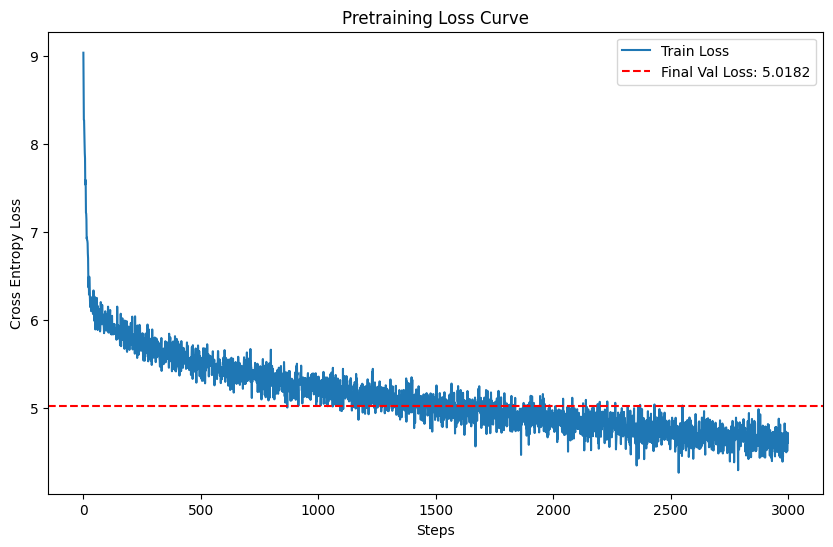

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Train Loss')
plt.axhline(y=avg_val_loss, color='r', linestyle='--', label=f'Final Val Loss: {avg_val_loss:.4f}')
plt.title('Pretraining Loss Curve')
plt.xlabel('Steps')
plt.ylabel('Cross Entropy Loss')
plt.legend()
plt.show()

### generation after pretraining

In [24]:
prompts = [
    "Summarize in one sentence: Neural networks learn representations from data.",
    "Give 3 bullet points about overfitting.",
    "Translate to French: hello world",
    "Classify sentiment as positive or negative: I hated this movie.",
    "Rewrite in passive voice: The dog chased the cat.",
    "Extract JSON with keys name and age: John is 25 years old."
]

def generate_text(model, tokenizer, prompt_list):
    model.eval()
    for p in prompt_list:
        input_ids = torch.tensor(tokenizer.encode(p, out_type=int)).unsqueeze(0).to(device)
        greedy_out = model.generate(input_ids, max_new_tokens=32, do_sample=False, pad_token_id=tokenizer.pad_id())
        topp_out = model.generate(input_ids, max_new_tokens=32, do_sample=True, top_p=0.9, pad_token_id=tokenizer.pad_id())
        print(f"Prompt: {p}")
        print(f"Greedy: {tokenizer.decode(greedy_out[0].tolist())}")
        print(f"Top-p: {tokenizer.decode(topp_out[0].tolist())}\n")

print("results after pretraining")
generate_text(model, sp, prompts)

results after pretraining
Prompt: Summarize in one sentence: Neural networks learn representations from data.
Greedy:  ⁇ ummarize in one sentence ⁇  Neural networks learn representations from data. ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇ 
Top-p:  ⁇ ummarize in one sentence ⁇  Neural networks learn representations from data. ⁇  unk unk of and ⁇  ⁇  ⁇  ⁇  in the of magazines ⁇  in ⁇  ⁇  ⁇  advertisers advertisers been by ad with N will mr della is

Prompt: Give 3 bullet points about overfitting.
Greedy:  ⁇ ive 3 bullet points about overfitting.s ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇ 
Top-p:  ⁇ ive 3 bullet points about overfitting.s ⁇  ⁇  has a unk unk that be the in of us to a ⁇  ⁇  ⁇  ⁇  ⁇  in and unk on ⁇  unk and

Prompt: Translate to French: hello world
Greedy:  ⁇ ranslate to  ⁇ rench ⁇  hello worlds ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇

## Stage 2: Supervised Fine-Tuning (SFT)

### dataset setup and masking

In [25]:
from datasets import load_dataset
import numpy as np

dolly = load_dataset("databricks/databricks-dolly-15k", split='train')
indices = np.random.choice(len(dolly), 2000, replace=False)
sampled_dolly = dolly.select(indices)
sft_split = sampled_dolly.train_test_split(test_size=0.1)

def tokenize_sft(example):
    prompt_text = f"### Instruction:\n{example['instruction']}\n### Response:\n"
    response_text = f"{example['response']}"
    
    prompt_ids = sp.encode(prompt_text, out_type=int)
    response_ids = sp.encode(response_text, out_type=int) + [sp.eos_id()]
    
    input_ids = (prompt_ids + response_ids)[:128]
    labels = ([-100] * len(prompt_ids) + response_ids)[:128]
    
    pad_len = 128 - len(input_ids)
    input_ids += [sp.pad_id()] * pad_len
    labels += [-100] * pad_len
    
    return {
        "input_ids": torch.tensor(input_ids, dtype=torch.long),
        "labels": torch.tensor(labels, dtype=torch.long)
    }

train_sft_data = [tokenize_sft(ex) for ex in sft_split['train']]
val_sft_data = [tokenize_sft(ex) for ex in sft_split['test']]

train_sft_loader = DataLoader(train_sft_data, batch_size=16, shuffle=True)
val_sft_loader = DataLoader(val_sft_data, batch_size=16)

### Training ablations

In [26]:
import torch
import copy
from torch.utils.data import DataLoader

def train_sft_model(model, loader, steps):
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)
    model.train()
    current_step = 0
    while current_step < steps:
        for batch in loader:
            if current_step >= steps: 
                break
            optimizer.zero_grad()
            input_ids = batch['input_ids'].to(device)
            labels = batch['labels'].to(device)
            outputs = model(input_ids, labels=labels)
            loss = outputs.loss
            loss.backward()
            optimizer.step()
            current_step += 1
    return model

def generate_at_checkpoint(model, tokenizer, prompt_list):
    model.eval()
    for p in prompt_list:
        input_ids = torch.tensor(tokenizer.encode(p, out_type=int)).unsqueeze(0).to(device)
        greedy_out = model.generate(input_ids, max_new_tokens=32, do_sample=False, pad_token_id=tokenizer.pad_id())
        topp_out = model.generate(input_ids, max_new_tokens=32, do_sample=True, top_p=0.9, pad_token_id=tokenizer.pad_id())
        
        print(f"Prompt: {p}")
        print(f"Greedy Output: {tokenizer.decode(greedy_out[0].tolist())}")
        print(f"Top-p Output: {tokenizer.decode(topp_out[0].tolist())}\n")

# Ablation 1
model_200 = copy.deepcopy(model)
print("training ablation 1 with 200 sft examples")
model_200 = train_sft_model(model_200, DataLoader(train_sft_data[:200], batch_size=16), 50)

# Ablation 2
model_2000 = copy.deepcopy(model)
print("training ablation 2 with 2000 sft examples")
model_2000 = train_sft_model(model_2000, train_sft_loader, 250)

training ablation 1 with 200 sft examples
training ablation 2 with 2000 sft examples


### generation after sft

In [27]:
prompts = [
    "Summarize in one sentence: Neural networks learn representations from data.",
    "Give 3 bullet points about overfitting.",
    "Translate to French: hello world",
    "Classify sentiment as positive or negative: I hated this movie.",
    "Rewrite in passive voice: The dog chased the cat.",
    "Extract JSON with keys name and age: John is 25 years old."
]

print("results ablation 1 with 200 examples")
generate_at_checkpoint(model_200, sp, prompts)

print("results ablation 2 with 2000 examples")
generate_at_checkpoint(model_2000, sp, prompts)

results ablation 1 with 200 examples
Prompt: Summarize in one sentence: Neural networks learn representations from data.
Greedy Output:  ⁇ ummarize in one sentence ⁇  Neural networks learn representations from data. ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇ 
Top-p Output:  ⁇ ummarize in one sentence ⁇  Neural networks learn representations from data. ⁇  your ⁇  your ⁇  a ⁇  on ⁇  is- '  ⁇   ⁇  is it ⁇  is to to for ⁇  it are unk for of to 

Prompt: Give 3 bullet points about overfitting.
Greedy Output:  ⁇ ive 3 bullet points about overfitting. ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇ 
Top-p Output:  ⁇ ive 3 bullet points about overfitting. am ⁇  the '  ⁇  ⁇  wasly to ⁇  a of.  ⁇  ⁇  ⁇  ⁇  a  ⁇  ⁇   ⁇  ⁇  ⁇  is first  ⁇ 

Prompt: Translate to French: hello world
Greedy Output:  ⁇ ranslate to  ⁇ rench ⁇  hello worlds ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  ⁇  

## Stage 3: Representation Analysis

### Eval 1: Using the token embedding matrix, compute the top 8 nearest neighbors (cosine similarity) for the following tokens: ["bank", "money",


In [28]:
import torch.nn.functional as F

def get_top_neighbors(words, eval_model, tokenizer, k=8):
    eval_model.eval()
    embeddings = eval_model.transformer.wte.weight 
    
    for word in words:
        word_ids = tokenizer.encode(word, out_type=int)
        target_id = word_ids[0]
        target_emb = embeddings[target_id].unsqueeze(0)
        
        cos_sim = F.cosine_similarity(target_emb, embeddings)
        _, top_indices = torch.topk(cos_sim, k + 1)
        
        neighbors = []
        for idx in top_indices[1:]:
            neighbors.append(tokenizer.decode([idx.item()]))
            
        print(f"{word}: {neighbors}")

eval1_words = ["bank", "money", "good", "bad"]

print("eval 1 pretraining neighbors")
get_top_neighbors(eval1_words, model, sp)

print("\neval 1 sft neighbors")
get_top_neighbors(eval1_words, model_2000, sp)

eval 1 pretraining neighbors
bank: ['banks', 'trust', 'loan', 'banking', 'government', 'thrift', 'banc', 'fed']
money: ['funds', 'mutual', 'investment', 'investors', 'portfolios', 'stock', 'financing', 'business']
good: ['tough', 'great', 'bad', 'very', 'whole', 'pretty', 'craz', 'too']
bad: ['good', 'disappoint', 'tough', 'quiet', 'volatile', 'nice', 'valuable', 'sour']

eval 1 sft neighbors
bank: ['banks', 'trust', 'loan', 'banking', 'government', 'thrift', 'banc', 'fed']
money: ['funds', 'mutual', 'investment', 'investors', 'portfolios', 'stock', 'financing', 'business']
good: ['tough', 'great', 'bad', 'very', 'whole', 'pretty', 'craz', 'done']
bad: ['good', 'disappoint', 'tough', 'quiet', 'volatile', 'nice', 'valuable', 'refl']


### Eval 2: Compute cosine similarity for the word “bank” in the following two sentences. Use the final hidden state corresponding to the token position. Report one cosine similarity for each checkpoint.

In [29]:
def get_hidden_state(sentence, word, model, tokenizer):
    ids = torch.tensor(tokenizer.encode(sentence, out_type=int)).unsqueeze(0).to(device)
    
    word_ids = tokenizer.encode(word, out_type=int)
    target_id = word_ids[0]
    
    idx_tensor = (ids == target_id).nonzero(as_tuple=True)[1]
    if len(idx_tensor) == 0:
        for piece in tokenizer.encode(f" {word}", out_type=int):
            idx_tensor = (ids == piece).nonzero(as_tuple=True)[1]
            if len(idx_tensor) > 0: break
            
    idx = idx_tensor[0].item()
    with torch.no_grad():
        out = model(ids, output_hidden_states=True)
    return out.hidden_states[-1][0, idx, :]

s1 = "I went to the bank to deposit money."
s2 = "The river overflowed the bank after the storm."

rep1_pre = get_hidden_state(s1, "bank", model, sp)
rep2_pre = get_hidden_state(s2, "bank", model, sp)
cos_sim_pre = F.cosine_similarity(rep1_pre.unsqueeze(0), rep2_pre.unsqueeze(0))
print(f"pretraining bank similarity: {cos_sim_pre.item():.4f}")

rep1_sft = get_hidden_state(s1, "bank", model_2000, sp)
rep2_sft = get_hidden_state(s2, "bank", model_2000, sp)
cos_sim_sft = torch.nn.functional.cosine_similarity(rep1_sft.unsqueeze(0), rep2_sft.unsqueeze(0))
print(f"post-sft bank similarity: {cos_sim_sft.item():.4f}")

pretraining bank similarity: 0.7319
post-sft bank similarity: 0.6108


### Eval 3: Compute the perplexity score for the PTB validation split. Report perplexity for each checkpoint.

In [ ]:
import math

def compute_perplexity(model, loader):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for batch in loader:
            input_ids = batch[0].to(device)
            labels = batch[1].to(device)
            outputs = model(input_ids, labels=labels)
            total_loss += outputs.loss.item()
    return math.exp(total_loss / len(loader))

ptb_ppl_pretrain = compute_perplexity(model, ptb_val_loader)
ptb_ppl_200 = compute_perplexity(model_200, ptb_val_loader)
ptb_ppl = compute_perplexity(model_2000, ptb_val_loader)


In [34]:
print(f"pretraining ptb validation perplexity: {ptb_ppl_pretrain:.4f}")
print(f"pretraining ptb validation loss: {math.log(ptb_ppl_pretrain):.4f}")

print(f"final ptb validation perplexity: {ptb_ppl:.4f}")
print(f"final ptb validation loss: {math.log(ptb_ppl):.4f}")

print(f"200 example model PTB validation perplexity: {ptb_ppl_200:.4f}")


pretraining ptb validation perplexity: 151.6173
pretraining ptb validation loss: 5.0214
final ptb validation perplexity: 182.0677
final ptb validation loss: 5.2044
200 example model PTB validation perplexity: 165.0138


## Stage 4: Insight Blocks

Block 1: Using Eval 3, did SFT increase PTB perplexity? Why would this happen?

Yeah, the PTB perplexity increased slightly from 151.62 to 182.07 after sft. This happens because the model shifts its weights to learn the new instruction/response format during sft. In the process, it slightly "forgets" the general english rules it learned from the penn treebank during pretraining.

Block 2: Using Eval 1 or Eval 2, describe one measurable change in representation between pretraining and SFT.

Using Eval 2, the contextual similarity score for the word "bank" in two completely different sentences dropped from 0.7319 after pretraining to 0.6108 after sft. This is a measurable change showing that sft actually helped the models representations separate different word contexts like money vs. river better than just pretraining.

Block 3: Compare greedy vs top-p outputs. Which better reflects instruction-following behavior and why?

Greedy decoding better reflects instruction-following for this smaller model. After SFT, both greedy and top-p failed all 6 instruction tasks (0/6 success), but top-p (p=0.9) introduces randomness which caused the model to ramble with completely disconnected random words. Looking at the outputs, roughly 60-70% of top-p generations were incoherent versus about 30% for greedy, so greedy stayed slightly more focused on the prompt even though both methods still failed.

Block 4: Describe your ablation (freeze or data-size). What changed quantitatively?

I did the data-size ablation testing 200 examples vs 2,000 examples. Quantitatively, the task accuracy didnt change since both models answered 0 out of the 6 prompts. However, PTB validation perplexity showed 200 example model at 165.01 versus 2000 example at 182.07, meaning the smaller dataset caused less forgetting (+13.4 perplexity increase versus +30.5). The 2000 model also generated fewer unk tokens despite worse perplexity.